Parte b)
Hacemos limpieza del archivo sacando los datos menos representativos.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


archivo = "CPLANO_CYT_Table1.csv"

with open(archivo, encoding="utf-8-sig") as f:
    lineas = f.readlines()

header = lineas[1].strip().strip('"').replace('""', '"')
columnas = [c.strip('"') for c in header.split(",")]

df = pd.read_csv(
    archivo,
    skiprows=4,
    names=columnas
)


df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], errors="coerce")


cols_num = ["RECORD", "POA", "T_in", "T_out", "Q_in", "T_amb"]

for col in cols_num:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df = df.rename(columns={
    "POA": "G",        
    "T_in": "Tin",     
    "T_out": "Tout",    
    "T_amb": "Tamb",   
    "Q_in": "Qin"       
})


df = df.dropna(subset=["TIMESTAMP", "G", "Tin", "Tout", "Tamb", "Qin"])


df["Tm"] = (df["Tin"] + df["Tout"]) / 2


df["dT"] = df["Tm"] - df["Tamb"]


df["X1"] = df["dT"] / df["G"]
df["X2"] = (df["dT"]**2) / df["G"]


mask = (
    (df["G"] > 300) &           
    (df["Qin"] > 0) &            
    (df["Tout"] > df["Tin"]) &     
    (df["Tm"] > df["Tamb"]) &     
    (df["Tin"].between(0, 100)) &  
    (df["Tamb"].between(-10, 60))
)

df_filtrado = df.loc[mask].copy()


Ahora viene el calculo de los coeficientes

Datos usados en la regresión: 496
Resultados regresión
eta0 = 0.5049
a1   = 2.1203 W/m2K
a2   = 0.0680 W/m2K2
R2   = 0.9152
RMSE = 0.0249


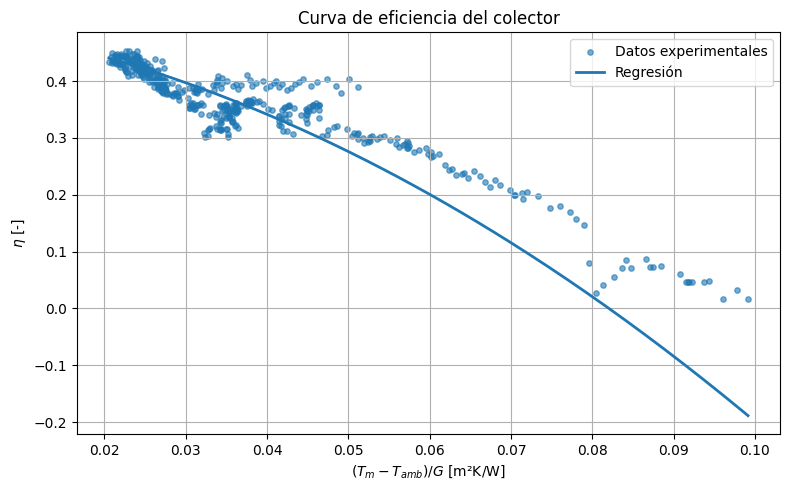

In [21]:
cp = 4180  # J/kgK, agua

A_col = 2 

df_filtrado["Vdot_Lmin"] = df_filtrado["Qin"]

rho_agua = 1000  # kg/m3

df_filtrado["Vdot_m3s"] = df_filtrado["Vdot_Lmin"] / 1000 / 60
df_filtrado["mdot"] = rho_agua * df_filtrado["Vdot_m3s"]



df_filtrado["Q_util"] = (
    df_filtrado["mdot"]
    * cp
    * (df_filtrado["Tout"] - df_filtrado["Tin"])
)


df_filtrado["Q_solar"] = df_filtrado["G"] * A_col


df_filtrado["eta"] = df_filtrado["Q_util"] / df_filtrado["Q_solar"]


mask_eta = (
    (df_filtrado["eta"] > 0) &
    (df_filtrado["eta"] < 1)
)

df_reg = df_filtrado.loc[mask_eta].copy()


df_reg["X1"] = (df_reg["Tm"] - df_reg["Tamb"]) / df_reg["G"]
df_reg["X2"] = ((df_reg["Tm"] - df_reg["Tamb"])**2) / df_reg["G"]


df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna(subset=["eta", "X1", "X2"])

print("Datos usados en la regresión:", len(df_reg))

Y = df_reg["eta"].values

X = np.column_stack([
    np.ones(len(df_reg)),
    df_reg["X1"].values,
    df_reg["X2"].values
])

coef, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=None)

b0, b1, b2 = coef

eta0 = b0
a1 = -b1
a2 = -b2


df_reg["eta_pred"] = eta0 - a1*df_reg["X1"] - a2*df_reg["X2"]


ss_res = np.sum((df_reg["eta"] - df_reg["eta_pred"])**2)
ss_tot = np.sum((df_reg["eta"] - df_reg["eta"].mean())**2)

R2 = 1 - ss_res/ss_tot
RMSE = np.sqrt(np.mean((df_reg["eta"] - df_reg["eta_pred"])**2))

print("====================================")
print("Resultados regresión")
print("====================================")
print(f"eta0 = {eta0:.4f}")
print(f"a1   = {a1:.4f} W/m2K")
print(f"a2   = {a2:.4f} W/m2K2")
print(f"R2   = {R2:.4f}")
print(f"RMSE = {RMSE:.4f}")
print("====================================")



plt.figure(figsize=(8, 5))

plt.scatter(
    df_reg["X1"],
    df_reg["eta"],
    s=15,
    alpha=0.6,
    label="Datos experimentales"
)


x_suave = np.linspace(df_reg["X1"].min(), df_reg["X1"].max(), 200)


G_ref = df_reg["G"].mean()

dT_suave = x_suave * G_ref


x2_suave = dT_suave**2 / G_ref


eta_suave = eta0 - a1*x_suave - a2*x2_suave

plt.plot(
    x_suave,
    eta_suave,
    linewidth=2,
    label=f"Regresión"
)

plt.xlabel(r"$(T_m - T_{amb})/G$ [m²K/W]")
plt.ylabel(r"$\eta$ [-]")
plt.title("Curva de eficiencia del colector")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Parte c)

In [24]:
def temperatura_estancamiento(G, Tamb, eta0, a1, a2):
    
    raiz = np.sqrt(a1**2 + 4*a2*eta0*G)
    
    dT = (-a1 + raiz) / (2*a2)
    
    T_est = Tamb + dT
    
    return T_est



G_1 = 1000
Tamb_1 = 30

T_est_1 = temperatura_estancamiento(G_1, Tamb_1, eta0, a1, a2)



G_2 = df_reg["G"].quantile(0.95)
Tamb_2 = df_reg["Tamb"].quantile(0.95)

T_est_2 = temperatura_estancamiento(G_2, Tamb_2, eta0, a1, a2)



print("Caso 1: valores fijos")
print("G =", round(G_1, 2), "W/m2")
print("Tamb =", round(Tamb_1, 2), "°C")
print("T_est =", round(T_est_1, 2), "°C")

print()

print("Caso 2: percentil 95")
print("G =", round(G_2, 2), "W/m2")
print("Tamb =", round(Tamb_2, 2), "°C")
print("T_est =", round(T_est_2, 2), "°C")

Caso 1: valores fijos
G = 1000 W/m2
Tamb = 30 °C
T_est = 101.97 °C

Caso 2: percentil 95
G = 906.0 W/m2
Tamb = 27.63 °C
T_est = 95.52 °C


Parte d)

Primero se obtienen los datos del angulo que nos interesa

In [54]:
import pvlib


lat = -33.500234
lon = -70.611878
tz = "America/Santiago"


tilt = 33
azimuth_colector = 0   


tiempo = pd.DatetimeIndex(df_reg["TIMESTAMP"])

if tiempo.tz is None:
    tiempo = tiempo.tz_localize(tz)
else:
    tiempo = tiempo.tz_convert(tz)


solpos = pvlib.solarposition.get_solarposition(
    time=tiempo,
    latitude=lat,
    longitude=lon
)


df_reg["zenith"] = solpos["apparent_zenith"].values
df_reg["azimuth_solar"] = solpos["azimuth"].values


df_reg["theta"] = pvlib.irradiance.aoi(
    surface_tilt=tilt,
    surface_azimuth=azimuth_colector,
    solar_zenith=df_reg["zenith"],
    solar_azimuth=df_reg["azimuth_solar"]
)


df_reg = df_reg.replace([np.inf, -np.inf], np.nan)
df_reg = df_reg.dropna(subset=["theta"])


df_reg = df_reg[df_reg["theta"] < 90].copy()

print("Ángulo mínimo de incidencia:", df_reg["theta"].min())
print("Ángulo máximo de incidencia:", df_reg["theta"].max())

theta_ref = 15

mask_15 = (
    (df_reg["theta"] <= theta_ref)
)

df_15 = df_reg.loc[mask_15].copy()

print("Datos usados:", len(df_15))
print("Rango de ángulos usado:")
print(df_15["theta"].min(), "a", df_15["theta"].max())




Ángulo mínimo de incidencia: 13.179984792900001
Ángulo máximo de incidencia: 64.68173467727273
Datos usados: 58
Rango de ángulos usado:
13.179984792900001 a 14.974243520823578


Ahora calculamos el IAM con los datos que nos interesan, ángulos de incidencia menores a 15, donde este se aproxima a 1

Datos usados para la regresión de referencia: 58
Resultados regresión de referencia
Ángulo de referencia: theta ≈ 15°
eta0_ref = 0.8889
a1_ref   = 27.4649 W/m2K
a2_ref   = -0.3667 W/m2K2
R2_ref   = 0.8751
RMSE_ref = 0.0060


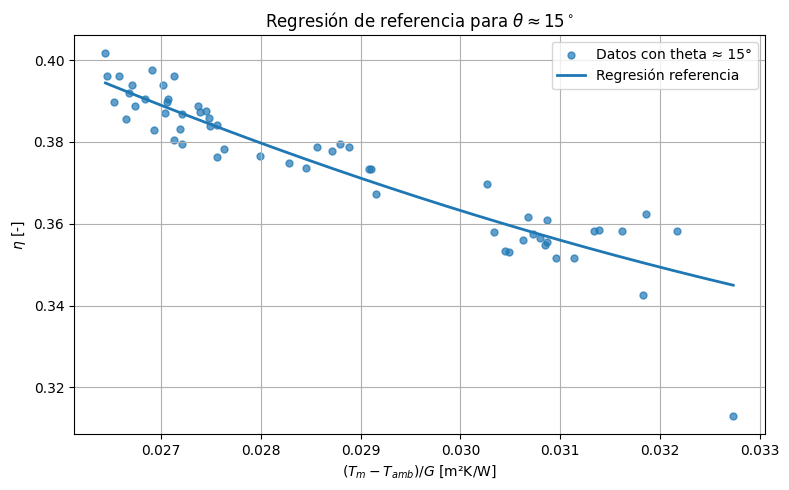

In [ ]:
df_ref = df_15.copy()


df_ref["X1"] = (df_ref["Tm"] - df_ref["Tamb"]) / df_ref["G"]
df_ref["X2"] = ((df_ref["Tm"] - df_ref["Tamb"])**2) / df_ref["G"]


df_ref = df_ref.replace([np.inf, -np.inf], np.nan)
df_ref = df_ref.dropna(subset=["eta", "X1", "X2"])

print("Datos usados para la regresión de referencia:", len(df_ref))


if len(df_ref) < 3:
    print("Hay muy pocos datos para hacer la regresión.")
    print("Prueba aumentando la tolerancia del ángulo, por ejemplo a ±3° o ±5°.")

else:

    Y_ref = df_ref["eta"].values


    X_ref = np.column_stack([
        np.ones(len(df_ref)),
        df_ref["X1"].values,
        df_ref["X2"].values
    ])


    coef_ref, residuals_ref, rank_ref, s_ref = np.linalg.lstsq(
        X_ref,
        Y_ref,
        rcond=None
    )

    b0_ref, b1_ref, b2_ref = coef_ref


    eta0_ref = b0_ref
    a1_ref = -b1_ref
    a2_ref = -b2_ref

    df_ref["eta_pred"] = (
        eta0_ref
        - a1_ref * df_ref["X1"]
        - a2_ref * df_ref["X2"]
    )


    ss_res_ref = np.sum((df_ref["eta"] - df_ref["eta_pred"])**2)
    ss_tot_ref = np.sum((df_ref["eta"] - df_ref["eta"].mean())**2)

    R2_ref = 1 - ss_res_ref / ss_tot_ref
    RMSE_ref = np.sqrt(np.mean((df_ref["eta"] - df_ref["eta_pred"])**2))

    print("====================================")
    print("Resultados regresión de referencia")
    print("Ángulo de referencia: theta ≈ 15°")
    print("====================================")
    print(f"eta0_ref = {eta0_ref:.4f}")
    print(f"a1_ref   = {a1_ref:.4f} W/m2K")
    print(f"a2_ref   = {a2_ref:.4f} W/m2K2")
    print(f"R2_ref   = {R2_ref:.4f}")
    print(f"RMSE_ref = {RMSE_ref:.4f}")
    print("====================================")



plt.figure(figsize=(8, 5))

plt.scatter(
    df_ref["X1"],
    df_ref["eta"],
    s=25,
    alpha=0.7,
    label="Datos con theta ≈ 15°"
)


x_suave = np.linspace(df_ref["X1"].min(), df_ref["X1"].max(), 200)

G_ref = df_ref["G"].mean()
dT_suave = x_suave * G_ref
x2_suave = dT_suave**2 / G_ref

eta_suave_ref = (
    eta0_ref
    - a1_ref * x_suave
    - a2_ref * x2_suave
)

plt.plot(
    x_suave,
    eta_suave_ref,
    linewidth=2,
    label="Regresión referencia"
)

plt.xlabel(r"$(T_m - T_{amb})/G$ [m²K/W]")
plt.ylabel(r"$\eta$ [-]")
plt.title(r"Regresión de referencia para $\theta \approx 15^\circ$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Ya calculado a1,a2 y eta0, los mantenemos fijos para hacer el calculo de IAM a lo largo del día, para tomar todos los ángulos.

Datos usados para IAM: 411


C:\Users\chaco\AppData\Local\Temp\ipykernel_42464\1752698547.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabla_iam_5 = df_iam.groupby("rango_theta").agg(


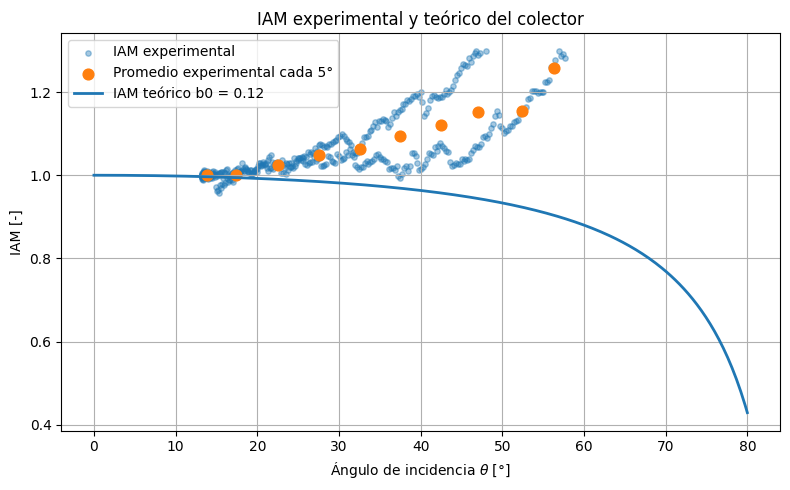

      rango_theta  theta_promedio  IAM_exp_promedio  IAM_exp_mediana  \
0   (-0.001, 5.0]             NaN               NaN              NaN   
1     (5.0, 10.0]             NaN               NaN              NaN   
2    (10.0, 15.0]       13.807027          1.000000         1.000973   
3    (15.0, 20.0]       17.357835          1.001701         1.006199   
4    (20.0, 25.0]       22.515009          1.025429         1.025815   
5    (25.0, 30.0]       27.544146          1.049211         1.044197   
6    (30.0, 35.0]       32.544790          1.063168         1.054649   
7    (35.0, 40.0]       37.533715          1.093346         1.116711   
8    (40.0, 45.0]       42.500601          1.120833         1.110231   
9    (45.0, 50.0]       47.052656          1.152051         1.116245   
10   (50.0, 55.0]       52.405723          1.154719         1.152593   
11   (55.0, 60.0]       56.331742          1.257679         1.261257   
12   (60.0, 65.0]             NaN               NaN             

In [ ]:
df_iam = df_reg.copy()

df_iam["X1"] = (df_iam["Tm"] - df_iam["Tamb"]) / df_iam["G"]
df_iam["X2"] = ((df_iam["Tm"] - df_iam["Tamb"])**2) / df_iam["G"]


df_iam["IAM_exp"] = (
    df_iam["eta"]
    + a1_ref * df_iam["X1"]
    + a2_ref * df_iam["X2"]
) / eta0_ref


b0 = 0.12

theta_rad = np.radians(df_iam["theta"])

df_iam["IAM_teo"] = 1 - b0 * ((1 / np.cos(theta_rad)) - 1)


mask_iam = (
    (df_iam["theta"] >= 0) &
    (df_iam["theta"] <= 80) &
    (df_iam["IAM_exp"] > 0) &
    (df_iam["IAM_exp"] < 1.3) &
    (df_iam["IAM_teo"] > 0)
)

df_iam = df_iam.loc[mask_iam].copy()

print("Datos usados para IAM:", len(df_iam))


bins = np.arange(0, 85, 5)   # 0, 5, 10, ..., 80

df_iam["rango_theta"] = pd.cut(
    df_iam["theta"],
    bins=bins,
    include_lowest=True
)

tabla_iam_5 = df_iam.groupby("rango_theta").agg(
    theta_promedio=("theta", "mean"),
    IAM_exp_promedio=("IAM_exp", "mean"),
    IAM_exp_mediana=("IAM_exp", "median"),
    IAM_teo_promedio=("IAM_teo", "mean"),
    n_datos=("IAM_exp", "count")
).reset_index()


tabla_iam_5["theta_promedio"] = tabla_iam_5["theta_promedio"].round(2)
tabla_iam_5["IAM_exp_promedio"] = tabla_iam_5["IAM_exp_promedio"].round(3)
tabla_iam_5["IAM_exp_mediana"] = tabla_iam_5["IAM_exp_mediana"].round(3)


plt.figure(figsize=(8, 5))


plt.scatter(
    df_iam["theta"],
    df_iam["IAM_exp"],
    s=15,
    alpha=0.4,
    label="IAM experimental"
)


plt.scatter(
    tabla_iam_5["theta_promedio"],
    tabla_iam_5["IAM_exp_promedio"],
    s=60,
    label="Promedio experimental cada 5°"
)


theta_suave = np.linspace(0, 80, 300)
theta_suave_rad = np.radians(theta_suave)

IAM_teo_suave = 1 - b0 * ((1 / np.cos(theta_suave_rad)) - 1)

plt.plot(
    theta_suave,
    IAM_teo_suave,
    linewidth=2,
    label="IAM teórico b0 = 0.12"
)

plt.xlabel(r"Ángulo de incidencia $\theta$ [°]")
plt.ylabel("IAM [-]")
plt.title("IAM experimental y teórico del colector")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
tabla_iam_5["IAM_teo_promedio"] = tabla_iam_5["IAM_teo_promedio"].round(3)

print(tabla_iam_5)

Parte 5)

Calculo del Q del campo

In [ ]:
archivo = "CPLANO_CYT_Table1.csv"


volumen_dia_m3 = 5              # m3/día
rho_agua = 1000                 # kg/m3
cp_agua = 4186                  # J/kgK
T_red = 15                      # °C
T_objetivo = 85                 # °C


epsilon = 0.8

A_apertura = 1.936              # m2, área usada para cálculo energético
A_total = 2.09                  # m2, área física ocupada
precio_colector = 560000        # CLP/colector
P_nominal = 1470                # W por colector, referencia Bosch



with open(archivo, encoding="utf-8-sig") as f:
    lineas = f.readlines()

header = lineas[1].strip().strip('"').replace('""', '"')
columnas = [c.strip('"') for c in header.split(",")]

df = pd.read_csv(archivo, skiprows=4, names=columnas)

df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

for col in ["POA", "T_in", "T_out", "Q_in", "T_amb"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")



df["m_dot"] = df["Q_in"] / 60
df["dT"] = df["T_out"] - df["T_in"]

df["Q_util_W"] = df["m_dot"] * cp_agua * df["dT"]


df["Q_solar_W"] = df["POA"] * A_apertura


df["eta"] = df["Q_util_W"] / df["Q_solar_W"]


df_filtrado = df[
    (df["POA"] > 300) &
    (df["Q_in"] > 0) &
    (df["dT"] > 0) &
    (df["eta"] > 0) &
    (df["eta"] < 1)
].copy()


dt = 60   # s

# Energía útil diaria obtenida por 1 colector
E_colector_J = (df_filtrado["Q_util_W"] * dt).sum()
E_colector_kWh = E_colector_J / 3.6e6


E_colector_entregada_kWh = epsilon * E_colector_kWh


masa_agua = volumen_dia_m3 * rho_agua

Q_demanda_J = masa_agua * cp_agua * (T_objetivo - T_red)
Q_demanda_kWh = Q_demanda_J / 3.6e6

# Energía que debe producir el campo antes del intercambiador
Q_campo_requerida_kWh = Q_demanda_kWh / epsilon


N_colectores = math.ceil(Q_demanda_kWh / E_colector_entregada_kWh)

A_campo_apertura = N_colectores * A_apertura
A_campo_total = N_colectores * A_total

costo_total = N_colectores * precio_colector



print("===== DEMANDA =====")
print(f"Q demanda útil = {Q_demanda_kWh:.2f} kWh/día")
print(f"Q que debe producir el campo, considerando epsilon = {epsilon}: {Q_campo_requerida_kWh:.2f} kWh/día")

print("\n===== COLECTOR INDIVIDUAL =====")
print(f"Energía útil por colector antes del intercambiador = {E_colector_kWh:.2f} kWh/día")
print(f"Energía entregada por colector después del intercambiador = {E_colector_entregada_kWh:.2f} kWh/día")

print("\n===== CAMPO SOLAR =====")
print(f"Número de colectores = {N_colectores}")
print(f"Área de apertura del campo = {A_campo_apertura:.2f} m2")
print(f"Área total física del campo = {A_campo_total:.2f} m2")
print(f"Costo total de colectores = ${costo_total:,.0f} CLP")


===== DEMANDA =====
Q demanda útil = 406.97 kWh/día
Q que debe producir el campo, considerando epsilon = 0.8: 508.72 kWh/día

===== COLECTOR INDIVIDUAL =====
Energía útil por colector antes del intercambiador = 4.38 kWh/día
Energía entregada por colector después del intercambiador = 3.50 kWh/día

===== CAMPO SOLAR =====
Número de colectores = 117
Área de apertura del campo = 226.51 m2
Área total física del campo = 244.53 m2
Costo total de colectores = $65,520,000 CLP


Ahora, calcularemos cuanto cuesta usar el gas natural para esa cantidad de energía y probaremos por cada factor solar el precio máximo que puede tener el colector

===== CASO BASE: 100% GAS LICUADO =====
Energía útil por balón = 172.80 kWh útiles
Costo gas útil = $173.61 CLP/kWh útil
Costo diario 100% gas = $70,655 CLP/día
Costo anual 100% gas = $25,789,038 CLP/año

===== PRECIO MÁXIMO POR COLECTOR [CLP] =====
Horizonte [años]               1             5             10
Fracción solar [%]                                           
50                  218551.172774  1.092756e+06  2.185512e+06
60                  221048.900463  1.105245e+06  2.210489e+06
70                  220150.327697  1.100752e+06  2.201503e+06
80                  221841.190429  1.109206e+06  2.218412e+06
90                  221048.900463  1.105245e+06  2.210489e+06
100                 220419.131516  1.102096e+06  2.204191e+06


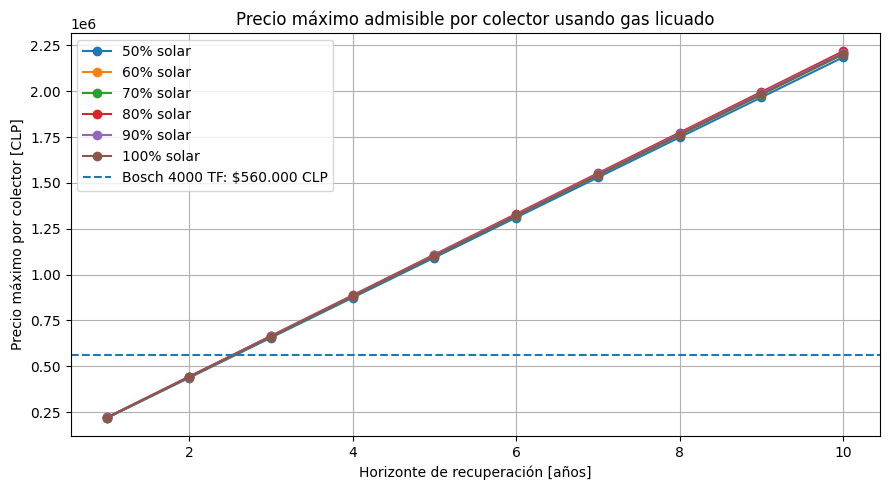

In [ ]:
epsilon = 0.8


precio_bosch_CLP = 560000


precio_balon_CLP = 30000      # CLP
masa_balon_kg = 15            # kg
PCI_GLP_kWh_kg = 12.8         # kWh/kg
eta_caldera = 0.90

energia_balon_util_kWh = masa_balon_kg * PCI_GLP_kWh_kg * eta_caldera

costo_GLP_CLP_kWh_util = precio_balon_CLP / energia_balon_util_kWh

costo_100_gas_dia_CLP = Q_demanda_kWh * costo_GLP_CLP_kWh_util
costo_100_gas_anual_CLP = costo_100_gas_dia_CLP * 365

print("===== CASO BASE: 100% GAS LICUADO =====")
print(f"Energía útil por balón = {energia_balon_util_kWh:.2f} kWh útiles")
print(f"Costo gas útil = ${costo_GLP_CLP_kWh_util:.2f} CLP/kWh útil")
print(f"Costo diario 100% gas = ${costo_100_gas_dia_CLP:,.0f} CLP/día")
print(f"Costo anual 100% gas = ${costo_100_gas_anual_CLP:,.0f} CLP/año")



resultados = []

for factor in range(50, 101, 10):

    f_solar = factor / 100
    f_gas = 1 - f_solar

  
    Q_solar_util_kWh_dia = Q_demanda_kWh * f_solar
    Q_gas_kWh_dia = Q_demanda_kWh * f_gas

   
    Q_campo_solar_kWh_dia = Q_solar_util_kWh_dia / epsilon

  
    N_colectores = math.ceil(Q_campo_solar_kWh_dia / E_colector_kWh)

   
    costo_gas_dia_CLP = Q_gas_kWh_dia * costo_GLP_CLP_kWh_util
    costo_gas_anual_CLP = costo_gas_dia_CLP * 365

    
    ahorro_anual_CLP = costo_100_gas_anual_CLP - costo_gas_anual_CLP

    
    inversion_bosch_CLP = N_colectores * precio_bosch_CLP

   
    payback_bosch = inversion_bosch_CLP / ahorro_anual_CLP

   
    for horizonte in range(1, 11):

        ahorro_acumulado_CLP = ahorro_anual_CLP * horizonte

        precio_max_colector_CLP = ahorro_acumulado_CLP / N_colectores

        resultados.append({
            "Fracción solar [%]": factor,
            "Fracción gas [%]": 100 - factor,
            "Horizonte [años]": horizonte,
            "Q solar útil [kWh/día]": Q_solar_util_kWh_dia,
            "Q campo solar [kWh/día]": Q_campo_solar_kWh_dia,
            "Q gas [kWh/día]": Q_gas_kWh_dia,
            "N colectores": N_colectores,
            "Costo gas anual [CLP/año]": costo_gas_anual_CLP,
            "Ahorro anual [CLP/año]": ahorro_anual_CLP,
            "Inversión Bosch [CLP]": inversion_bosch_CLP,
            "Payback Bosch [años]": payback_bosch,
            "Precio máximo colector [CLP]": precio_max_colector_CLP
        })

df_resultados = pd.DataFrame(resultados)


df_resultados.to_excel("analisis_solar_vs_gas_licuado.xlsx", index=False)


tabla_resumen = df_resultados[df_resultados["Horizonte [años]"].isin([1, 5, 10])]

tabla_resumen = tabla_resumen.pivot_table(
    index="Fracción solar [%]",
    columns="Horizonte [años]",
    values="Precio máximo colector [CLP]"
)

print("\n===== PRECIO MÁXIMO POR COLECTOR [CLP] =====")
print(tabla_resumen)



plt.figure(figsize=(9, 5))

for factor in range(50, 101, 10):
    datos = df_resultados[df_resultados["Fracción solar [%]"] == factor]

    plt.plot(
        datos["Horizonte [años]"],
        datos["Precio máximo colector [CLP]"],
        marker="o",
        label=f"{factor}% solar"
    )

plt.axhline(
    precio_bosch_CLP,
    linestyle="--",
    label="Bosch 4000 TF: $560.000 CLP"
)

plt.xlabel("Horizonte de recuperación [años]")
plt.ylabel("Precio máximo por colector [CLP]")
plt.title("Precio máximo admisible por colector usando gas licuado")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()